# N03 - Application: Floquet-Controlled Tunnelling
## Bessel-renormalized hopping, micromotion, quasienergy gauge, and Floquet-replica failure

Periodic driving can replace a bare tunnelling amplitude by a controllable effective one, including strong suppression and sign reversal. The central lesson is that a Floquet Hamiltonian is only one part of the prediction: continuous-time laboratory observables also require the periodic frame transformation and, beyond leading order, residual kick or micromotion corrections.

$$
\boxed{\text{effective generator}+\text{micromotion}+\text{quasienergy convention}
=\text{complete Floquet prediction}.}
$$

## 1. Motivation and applications

Dynamic localization in a driven lattice was identified by Dunlap and Kenkre, while coherent destruction of tunnelling was formulated in the Floquet spectrum of a driven double well by Grossmann, Dittrich, Jung, and Hänggi. The phenomenon was subsequently visualized in a driven optical double well by Della Valle *et al.* and observed for matter waves in strongly driven double-well and optical-lattice experiments by Kierig *et al.*, Lignier *et al.*, and Zenesini *et al.*

The same structure is now part of the standard Floquet-engineering toolkit: a periodic change of frame converts a force into a time-dependent Peierls phase, harmonic averaging produces a Bessel-renormalized hopping, and quasienergies describe the stroboscopic spectrum. The effective generator alone is not sufficient for phase-sensitive observables because the laboratory state contains periodic micromotion.

For interacting systems, high-frequency driving can generate a long prethermal window without describing the infinite-time state. This distinction is experimentally relevant: Floquet prethermalization has been observed in driven Bose-Hubbard systems and in long-lived driven spin ensembles. Conversely, when one or more Floquet replicas become nearly resonant, the appropriate reduced model is a resonant Sambe-space block rather than a nonresonant average. This distinction is also important in quantum control, where degenerate-Floquet perturbation theory organizes multiphoton couplings, drive-induced shifts, leakage channels, and reconstruction operators within one framework.


## 2. Learning goals and claim-diagnostic map

After completing the notebook, the reader should be able to:

1. derive the exact accelerated-frame transformation for a periodically tilted lattice;
2. obtain $J_{\mathrm{eff}}=J\mathcal J_0(K/\omega)$ from the Jacobi-Anger expansion;
3. distinguish ordinary tunnelling, leading-order coherent destruction, and sign-inverted hopping;
4. compute the exact one-period propagator and quasienergies with QuTiP;
5. compare quasienergies only after choosing a consistent Floquet zone;
6. reconstruct a micromotion-sensitive current in the laboratory frame;
7. verify the leading Floquet result independently in truncated Sambe space;
8. identify the first failure when a Floquet replica enters the dynamical window.

| Physical claim | Primary observable | Required diagnostic | First repair |
|---|---|---|---|
| Bessel-renormalized hopping | transfer probability and quasienergy splitting | $\mathcal J_0(K/\omega)$, exact one-period spectrum | include higher-order harmonics |
| coherent destruction | residual transfer near a zero of $\mathcal J_0$ | finite-frequency residual motion | higher-order van Vleck / Sambe block |
| continuous-time prediction | bond current or coherence | exact frame reconstruction and state distance | restore micromotion |
| high-frequency validity | stroboscopic state distance | drive-frequency scan and Floquet-zone separation | retain resonant replicas |
| sign reversal | dispersion or loop interference | compare spectra in a non-bipartite geometry | retain the sign of $J_{\rm eff}$ |

### Two reading paths

**Manuscript-support path.** Sections 3--8 and 10--12 derive and validate the statements used directly in the article: exact frame transformation, Bessel-renormalized hopping, exact quasienergies, the four-panel manuscript benchmark, micromotion reconstruction, and finite-frequency breakdown near the first Bessel zero.

**Independent-learning path.** Sections 9, 13, and 14 go beyond the minimal manuscript benchmark. They develop Sambe-space truncation, the gauge meaning of hopping-sign reversal, and a finite interacting example. These sections are useful for learning and for designing extensions, but they are not required to reproduce the manuscript's minimal validation figure.


## 3. Manuscript schematic

The laboratory-frame force, exact periodic transformation, Bessel-renormalized hopping, three tunnelling regimes, and the role of micromotion are summarized in the canonical schematic used in the article.

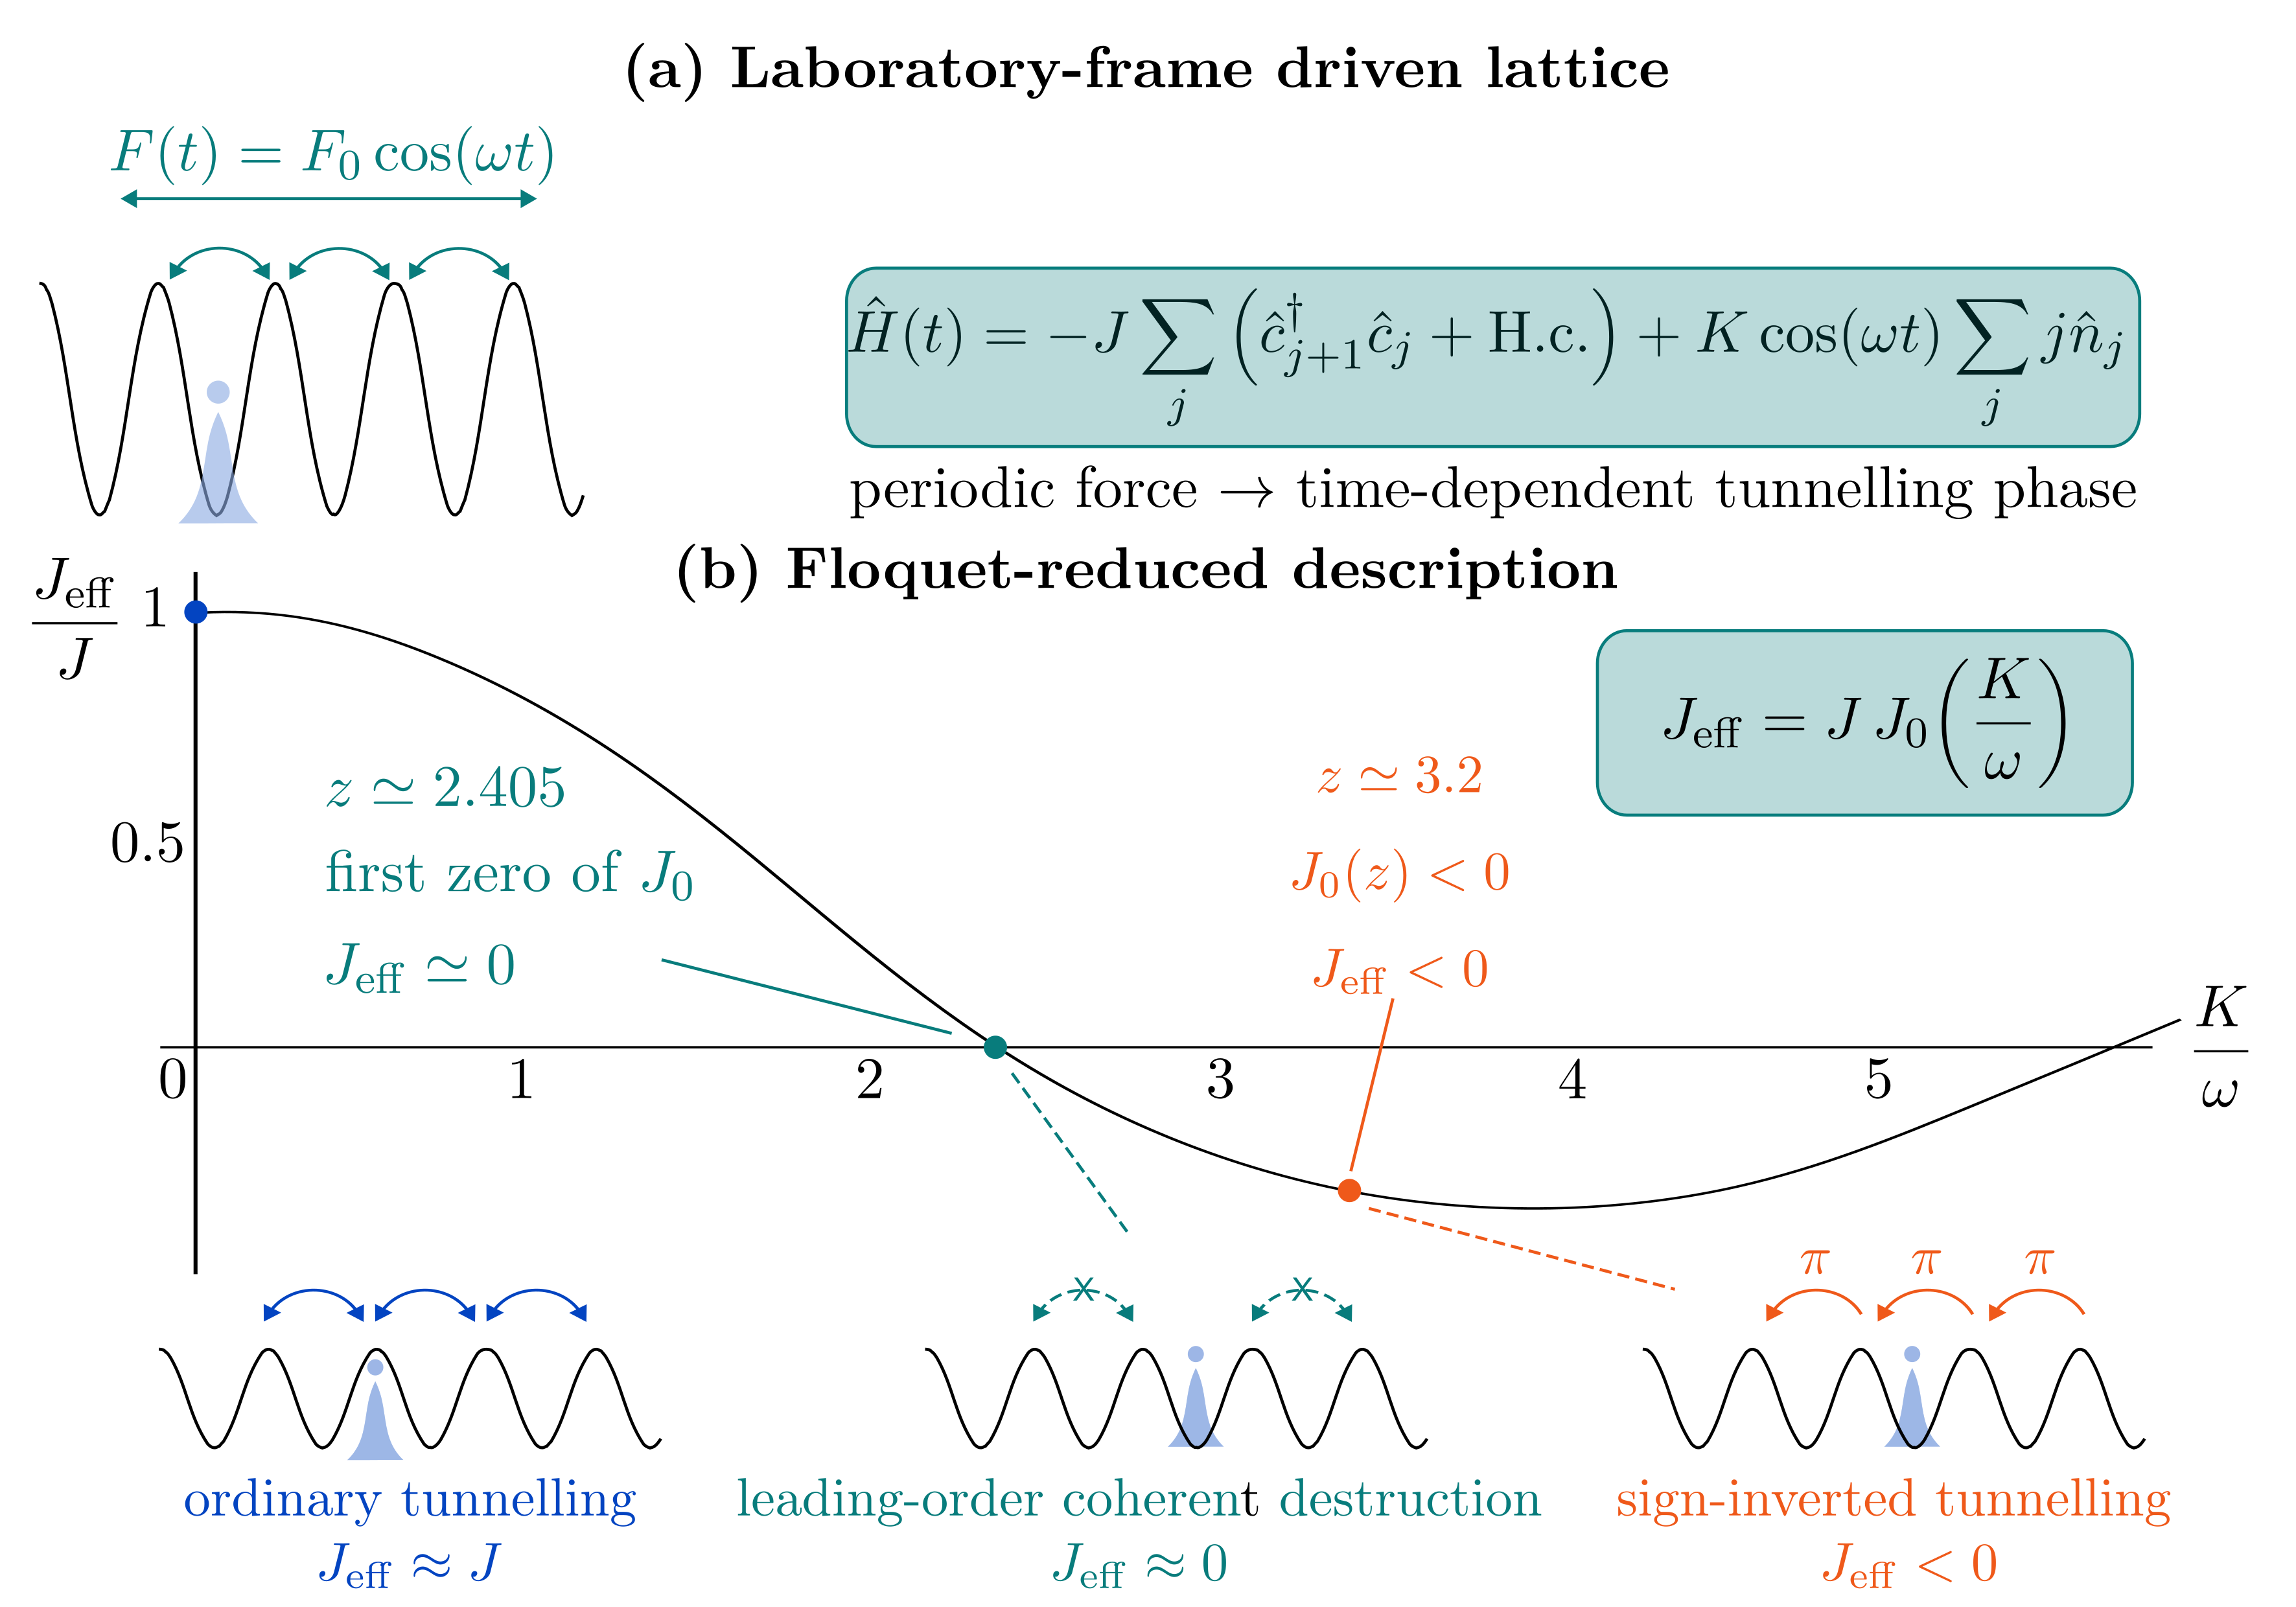

In [1]:
from hashlib import sha256
import shutil
from pathlib import Path
from IPython.display import Image, display

asset_pdf = Path("assets/manuscript/N03_MF1.pdf")
asset_png = Path("assets/manuscript/N03_MF1.png")
target_dir = Path("figures/manuscript")
target_dir.mkdir(parents=True, exist_ok=True)
target_pdf = target_dir / "N03_MF1.pdf"
target_png = target_dir / "N03_MF1.png"
shutil.copy2(asset_pdf, target_pdf)
shutil.copy2(asset_png, target_png)
assert sha256(asset_pdf.read_bytes()).hexdigest() == "518a91a76c5fe52aa9fda7d21d1e910c3d418b6b29ef747a1356bcadedd09340"
assert sha256(target_pdf.read_bytes()).hexdigest() == "518a91a76c5fe52aa9fda7d21d1e910c3d418b6b29ef747a1356bcadedd09340"
display(Image(filename=str(target_png), width=920))

**Manuscript Figure N03_MF1. Floquet control of tunnelling.**
A periodic force is removed by an exact accelerated-frame transformation and reappears as a time-dependent Peierls phase. Its zeroth harmonic gives $J_{\rm eff}=J\mathcal J_0(K/\omega)$, producing ordinary tunnelling, leading-order coherent destruction, and sign inversion. Continuous-time laboratory observables require the periodic reconstruction in addition to the effective generator.

## 4. Model and exact driven frame

For a nearest-neighbour lattice,
$$
H(t)=
-J\sum_j\left(c_{j+1}^\dagger c_j+\mathrm{H.c.}\right)
+K\cos(\omega t)\,X+H_{\rm int},
\qquad
X=\sum_j j\,n_j .
$$

Define
$$
R(t)=\exp\!\left[-i\frac{K}{\omega}\sin(\omega t)\,X\right],
\qquad
|\widetilde\psi(t)\rangle=R^\dagger(t)|\psi(t)\rangle.
$$
With
$$
\widetilde H(t)=R^\dagger H(t)R-iR^\dagger\dot R,
$$
one obtains
$$
\widetilde H(t)
=
-J\sum_j\left[
e^{i\alpha\sin(\omega t)}c_{j+1}^\dagger c_j+\mathrm{H.c.}
\right]
+\widetilde H_{\rm int}(t),
\qquad
\alpha=\frac{K}{\omega},
$$
where
$$
\widetilde H_{\rm int}(t)=R^\dagger(t)H_{\rm int}R(t).
$$
On-site interactions and density-density interactions commute with $X$ and therefore remain unchanged. More general interaction or conversion terms acquire their own periodic phases and harmonics.

This frame transformation is exact. The approximation begins only when the harmonic content of $\widetilde H(t)$ is truncated or perturbatively block diagonalized.

Using
$$
e^{i\alpha\sin(\omega t)}
=\sum_{m=-\infty}^{\infty}\mathcal J_m(\alpha)e^{im\omega t},
$$
the zeroth-order Floquet Hamiltonian has
$$
H_F^{(0)}=
-J\mathcal J_0(\alpha)\sum_j(c_{j+1}^\dagger c_j+\mathrm{H.c.})
+H_{\rm int}
$$
when $[H_{\rm int},X]=0$. Thus
$$
J_{\rm eff}=J\mathcal J_0(\alpha).
$$

At a zero of $\mathcal J_0$, the **leading generator** predicts vanishing tunnelling. Finite-frequency corrections can still produce residual motion, so a Bessel zero should not be described as exact localization at arbitrary $\omega/J$.

### Complete Floquet prediction

In a chosen Floquet gauge the laboratory propagator can be written as
$$
U(t,0)=
R(t)e^{-i\mathcal K(t)}e^{-iH_F t}
e^{i\mathcal K(0)}R^\dagger(0),
\qquad
\mathcal K(t+T)=\mathcal K(t),
$$
where $\mathcal K(t)$ is the periodic kick operator. The calligraphic symbol distinguishes it from the drive amplitude $K$.

At leading order, retaining the exact periodic frame while neglecting residual kick corrections gives
$$
|\psi_{\rm rec}(t)\rangle
=R(t)e^{-iH_F^{(0)}t}|\psi(0)\rangle.
$$
This is the reconstruction used below. Any remaining discrepancy records higher-order Floquet drift and kick corrections, not a failure of the exact frame transformation.


## 5. QuTiP model

The manuscript validation uses the driven two-site sector because it exposes the Floquet structure without unrelated finite-chain effects. A non-bipartite ring and an interacting dimer are retained later as controlled extensions.

### Numerical convention and QuTiP help

For the two-site calculation we use the centered position operator
$$
X_{\rm c}=-\frac12|L\rangle\langle L|
+\frac12|R\rangle\langle R|.
$$
It differs from the manuscript convention $X=\sum_j j n_j$ only by a multiple
of the identity, so the corresponding periodic transformation differs only by
a global phase. Populations, currents, density matrices, and quasienergy
differences are unchanged.

The principal QuTiP objects used below can be inspected directly inside Jupyter:
`qt.QobjEvo?`, `qt.sesolve?`, `qt.propagator?`, and `qt.FloquetBasis?`.
The model parameters that readers will most often change are `J`,
`omega_main`, `alpha_ordinary`, `alpha_zero`, and `alpha_inverted`.


In [2]:
from pathlib import Path
import json
import platform
import sys
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy.special import jv, jn_zeros

import qutip as qt
from qutip import (
    QobjEvo,
    FloquetBasis,
    basis,
    destroy,
    expect,
    ket2dm,
    propagator,
    qeye,
    sesolve,
    tensor,
    tracedist,
)

logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

plt.style.use(["science", "notebook"])

# Match N08 / SciPost manuscript typography and line styling.
# All generated figures use a physical canvas width of exactly 150 mm.
FIG_WIDTH_150MM = 150.0 / 25.4
SCIPOST_FONT_SIZE = 10.95
DOT_STYLE = (0, (1.0, 2.2))

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "text.usetex": True,
    "font.family": "serif",
    "font.size": SCIPOST_FONT_SIZE,
    "axes.labelsize": SCIPOST_FONT_SIZE,
    "axes.titlesize": SCIPOST_FONT_SIZE,
    "legend.fontsize": SCIPOST_FONT_SIZE,
    "xtick.labelsize": SCIPOST_FONT_SIZE,
    "ytick.labelsize": SCIPOST_FONT_SIZE,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.35,
    "lines.markersize": 4.2,
    "axes.formatter.use_mathtext": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
})

ROOT = Path.cwd()
FIG_MANUSCRIPT = ROOT / "figures" / "manuscript"
FIG_NOTEBOOK = ROOT / "figures" / "notebook"
DATA_DIR = ROOT / "data"
for directory in (FIG_MANUSCRIPT, FIG_NOTEBOOK, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SOLVER = {
    "method": "dop853",
    "atol": 1e-11,
    "rtol": 1e-9,
    "nsteps": 30000,
    "store_states": True,
    "progress_bar": False,
}

def save_figure(fig, stem, manuscript=False):
    directory = FIG_MANUSCRIPT if manuscript else FIG_NOTEBOOK
    modified_stem = f"{stem}"
    # Do not use bbox_inches="tight": it would change the physical 150 mm canvas.
    fig.savefig(directory / f"{modified_stem}.pdf", dpi=600)
    fig.savefig(directory / f"{modified_stem}.png", dpi=600)

def save_table(frame, stem):
    frame.to_csv(DATA_DIR / f"{stem}.csv", index=False)

# Two-site basis: |L> = |0>, |R> = |1>.
ket_L = basis(2, 0)
ket_R = basis(2, 1)
P_L = ket2dm(ket_L)
P_R = ket2dm(ket_R)

T_RL = ket_R * ket_L.dag()
T_LR = T_RL.dag()

# Centering X changes R(t) only by a global phase relative to X = sum_j j n_j.
X = -0.5 * P_L + 0.5 * P_R

def drive_coeff(t, args):
    return args["alpha"] * args["omega"] * np.cos(args["omega"] * t)

def peierls_plus(t, args):
    return np.exp(1j * args["alpha"] * np.sin(args["omega"] * t))

def peierls_minus(t, args):
    return np.exp(-1j * args["alpha"] * np.sin(args["omega"] * t))

def lab_hamiltonian(J, omega, alpha, bias=0.0):
    H0 = -J * (T_RL + T_LR) + 0.5 * bias * (P_R - P_L)
    return QobjEvo(
        [H0, [X, drive_coeff]],
        args={"alpha": alpha, "omega": omega},
    )

def accelerated_hamiltonian(J, omega, alpha, bias=0.0):
    H_bias = 0.5 * bias * (P_R - P_L)
    return QobjEvo(
        [
            H_bias,
            [-J * T_RL, peierls_plus],
            [-J * T_LR, peierls_minus],
        ],
        args={"alpha": alpha, "omega": omega},
    )

def frame_unitary(t, omega, alpha):
    return (-1j * alpha * np.sin(omega * t) * X).expm()

def leading_floquet_hamiltonian(J, alpha, bias=0.0):
    J_eff = J * jv(0, alpha)
    return -J_eff * (T_RL + T_LR) + 0.5 * bias * (P_R - P_L)

def lab_current_operator(J):
    # Positive current increases the right-site population.
    return 1j * J * (T_RL - T_LR)

def slow_current_operator(J, alpha):
    J_eff = J * jv(0, alpha)
    return 1j * J_eff * (T_RL - T_LR)

def fold_zone(values, omega):
    values = np.asarray(values, dtype=float)
    return ((values + 0.5 * omega) % omega) - 0.5 * omega

J = 1.0
omega_main = 12.0
alpha_ordinary = 1.2
alpha_zero = float(jn_zeros(0, 1)[0])
alpha_inverted = 3.2


## 6. Exact frame transformation: numerical identity

The accelerated frame is not an approximation. We solve the laboratory Hamiltonian and the exactly transformed Hamiltonian independently with `sesolve`, reconstruct $R(t)|\widetilde\psi(t)\rangle$, and compare density operators using the QuTiP trace distance.

In [3]:
T_main = 2 * np.pi / omega_main
t_frame = np.linspace(0.0, 4 * T_main, 401)

H_lab_frame = lab_hamiltonian(J, omega_main, alpha_ordinary)
H_acc_frame = accelerated_hamiltonian(J, omega_main, alpha_ordinary)

out_lab_frame = sesolve(H_lab_frame, ket_L, t_frame, options=SOLVER)
out_acc_frame = sesolve(H_acc_frame, ket_L, t_frame, options=SOLVER)

states_reconstructed_exact_frame = [
    frame_unitary(t, omega_main, alpha_ordinary) * state
    for t, state in zip(t_frame, out_acc_frame.states)
]

frame_distances = np.array([
    tracedist(ket2dm(a), ket2dm(b))
    for a, b in zip(out_lab_frame.states, states_reconstructed_exact_frame)
])

frame_validation = pd.DataFrame({
    "t": t_frame,
    "trace_distance_lab_vs_exact_frame": frame_distances,
})
save_table(frame_validation, "N03_D1")

pd.DataFrame({
    "quantity": ["max_exact_frame_trace_distance"],
    "value": [frame_distances.max()],
})

,quantity,value
0,max_exact_frame_trace_distance,3.784058e-15


The residual above is purely numerical. It separates the **exact representation change** from the later Floquet approximation.

## 7. Leading Floquet generator and three tunnelling regimes

The Bessel law produces three qualitatively different regimes:

$$
\mathcal J_0(\alpha)\approx 1:
\text{ ordinary tunnelling},
$$
$$
\mathcal J_0(\alpha)\approx 0:
\text{ leading-order coherent destruction},
$$
$$
\mathcal J_0(\alpha)<0:
\text{ sign-inverted hopping}.
$$

For an isolated two-site bond the sign can be removed by a local gauge transformation. It becomes observable when several paths interfere, for example in a loop, through band dispersion, or in frustrated geometries.

In [4]:
regime_table = pd.DataFrame({
    "regime": ["ordinary", "first Bessel zero", "sign inverted"],
    "alpha": [alpha_ordinary, alpha_zero, alpha_inverted],
    "J0": [jv(0, alpha_ordinary), jv(0, alpha_zero), jv(0, alpha_inverted)],
    "J_eff_over_J": [jv(0, alpha_ordinary), jv(0, alpha_zero), jv(0, alpha_inverted)],
})
save_table(regime_table, "N03_D2")
regime_table

,regime,alpha,J0,J_eff_over_J
0,ordinary,1.200000,6.711327e-01,6.711327e-01
1,first Bessel zero,2.404826,1.023923e-16,1.023923e-16
2,sign inverted,3.200000,-3.201882e-01,-3.201882e-01


## 8. Exact quasienergies with QuTiP

Quasienergies are defined modulo $\omega$. QuTiP's `FloquetBasis` constructs the exact one-period Floquet basis directly from the time-dependent `QobjEvo`. The leading generator is compared only after both spectra are placed in the same principal zone.

In [5]:
H_lab_qe = lab_hamiltonian(J, omega_main, alpha_ordinary)
floquet_basis = FloquetBasis(H_lab_qe, T_main, options=SOLVER)

quasi_exact = np.sort(np.asarray(floquet_basis.e_quasi, dtype=float))
quasi_eff = np.sort(fold_zone(
    leading_floquet_hamiltonian(J, alpha_ordinary).eigenenergies(),
    omega_main,
))

U_T = propagator(H_lab_qe, T_main, options=SOLVER)
unitarity_residual = (U_T.dag() * U_T - qeye(2)).norm()
quasi_residual = np.max(np.abs(quasi_exact - quasi_eff))

quasienergy_table = pd.DataFrame({
    "branch": [0, 1],
    "exact_quasienergy": quasi_exact,
    "leading_floquet": quasi_eff,
    "difference": quasi_exact - quasi_eff,
})
save_table(quasienergy_table, "N03_D3")

pd.DataFrame({
    "quantity": ["one_period_unitarity_residual", "leading_quasienergy_residual"],
    "value": [unitarity_residual, quasi_residual],
})

,quantity,value
0,one_period_unitarity_residual,4.501348e-10
1,leading_quasienergy_residual,5.840617e-03


## 9. Independent-learning extension I: Sambe-space check

The extended Floquet or Sambe space makes harmonic connectivity explicit. With
$$
\widetilde H(t)=\sum_m H_m e^{im\omega t},
$$
the Fourier blocks are
$$
H_m=-J\left[
\mathcal J_m(\alpha)\,|R\rangle\langle L|
+\mathcal J_{-m}(\alpha)\,|L\rangle\langle R|
\right].
$$

The Sambe Hamiltonian
$$
(\mathcal H_S)_{mn}=H_{m-n}+m\omega\,\delta_{mn}
$$
is truncated at $|m|\le M$. The two eigenstates carrying the largest weight in the central harmonic are compared with the exact QuTiP quasienergies.

In [6]:
def fourier_block(order, J, alpha, bias=0.0):
    block = -J * (
        jv(order, alpha) * T_RL
        + jv(-order, alpha) * T_LR
    )
    if order == 0:
        block += 0.5 * bias * (P_R - P_L)
    return block

def sambe_hamiltonian(J, omega, alpha, M, bias=0.0):
    harmonics = np.arange(-M, M + 1)
    nh = len(harmonics)
    Hs = 0 * tensor(qeye(nh), qeye(2))

    for p, m in enumerate(harmonics):
        ket_m = basis(nh, p)
        Hs += m * omega * tensor(ket_m * ket_m.dag(), qeye(2))
        for q, n in enumerate(harmonics):
            ket_n = basis(nh, q)
            Hs += tensor(
                ket_m * ket_n.dag(),
                fourier_block(m - n, J, alpha, bias=bias),
            )
    return Hs

def central_sambe_quasienergies(J, omega, alpha, M, bias=0.0):
    Hs = sambe_hamiltonian(J, omega, alpha, M, bias=bias)
    evals, evecs = Hs.eigenstates()
    nh = 2 * M + 1
    central = basis(nh, M)
    P_central = tensor(central * central.dag(), qeye(2))
    weights = np.array([expect(P_central, state) for state in evecs], dtype=float)
    chosen = np.argsort(weights)[-2:]
    q = np.sort(fold_zone(np.asarray(evals)[chosen], omega))
    return q, np.sort(weights[chosen])

sambe_rows = []
for M in range(1, 7):
    q_sambe, central_weights = central_sambe_quasienergies(
        J, omega_main, alpha_ordinary, M
    )
    sambe_rows.append({
        "M": M,
        "max_quasienergy_error": np.max(np.abs(q_sambe - quasi_exact)),
        "minimum_central_harmonic_weight": central_weights.min(),
    })

sambe_table = pd.DataFrame(sambe_rows)
save_table(sambe_table, "N03_D4")
sambe_table

,M,max_quasienergy_error,minimum_central_harmonic_weight
0,1,6.163805e-04,0.996423
1,2,1.579217e-05,0.996314
2,3,3.436045e-07,0.996312
3,4,3.933683e-09,0.996311
4,5,3.779810e-11,0.996311
5,6,2.883249e-13,0.996311


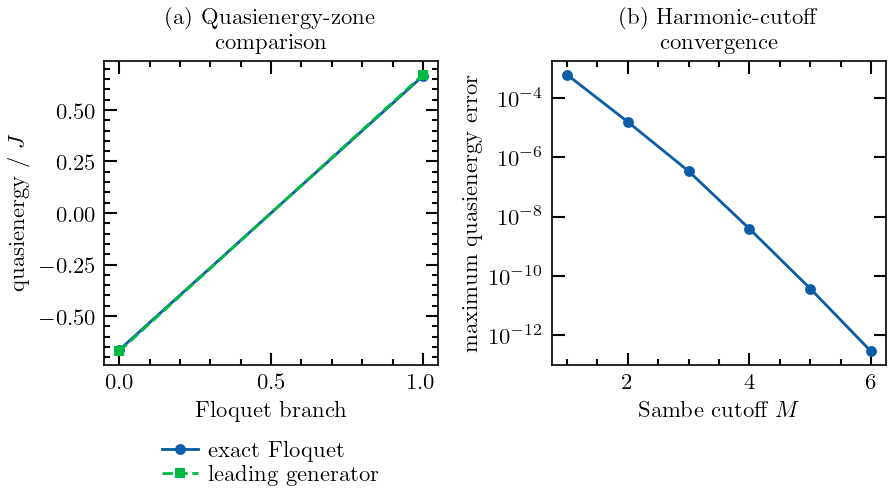

In [7]:
fig = plt.figure(figsize=(FIG_WIDTH_150MM, 3.05))
gs = fig.add_gridspec(
    1, 2,
    left=0.105, right=0.988, bottom=0.235, top=0.90,
    wspace=0.34,
)
axes = np.array([fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])])

axes[0].plot(quasienergy_table["branch"], quasi_exact, "o-", label="exact Floquet")
axes[0].plot(quasienergy_table["branch"], quasi_eff, "s--", label="leading generator")
axes[0].set(
    xlabel="Floquet branch",
    ylabel=r"quasienergy / $J$",
    title="(a) Quasienergy-zone\ncomparison",
)
axes[0].legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.50, -0.22),
    ncol=1,
    handlelength=1.55,
    handletextpad=0.45,
    labelspacing=0.15,
    borderaxespad=0.0,
)

axes[1].semilogy(
    sambe_table["M"],
    sambe_table["max_quasienergy_error"],
    "o-",
)
axes[1].set(
    xlabel=r"Sambe cutoff $M$",
    ylabel="maximum quasienergy error",
    title="(b) Harmonic-cutoff\nconvergence",
)

save_figure(fig, "N03_F1")
plt.show()
plt.close(fig)


**Figure N03_F1.** Exact quasienergies and an independent Sambe-space convergence check. The principal-zone comparison is meaningful here because the two quasienergies remain well separated from the Floquet-zone boundary.

## 10. Manuscript quantitative figure

The manuscript figure separates four statements that should not be conflated: Bessel renormalization, ordinary driven transfer, the finite-frequency residual at a Bessel zero, and the micromotion dependence of a current.

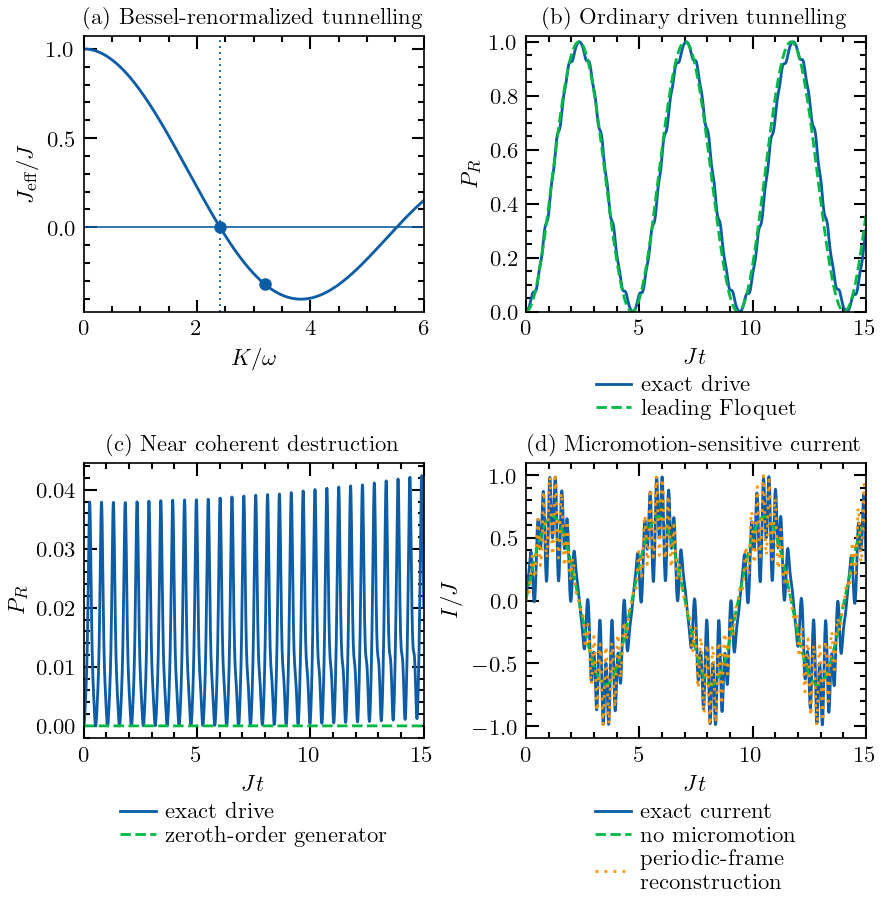

,quantity,value
0,max_current_error_generator_only,0.498967
1,max_current_error_periodic_frame,0.300331
2,improvement_factor,1.661390


In [8]:
t_main = np.linspace(0.0, 15.0 / J, 1201)

# Ordinary driven tunnelling.
H_lab_ord = lab_hamiltonian(J, omega_main, alpha_ordinary)
H_eff_ord = leading_floquet_hamiltonian(J, alpha_ordinary)
out_ord_exact = sesolve(H_lab_ord, ket_L, t_main, options=SOLVER)
out_ord_eff = sesolve(H_eff_ord, ket_L, t_main, options=SOLVER)

P_R_ord_exact = np.asarray(expect(P_R, out_ord_exact.states), dtype=float)
P_R_ord_eff = np.asarray(expect(P_R, out_ord_eff.states), dtype=float)

# First Bessel zero.
H_lab_cdt = lab_hamiltonian(J, omega_main, alpha_zero)
H_eff_cdt = leading_floquet_hamiltonian(J, alpha_zero)
out_cdt_exact = sesolve(H_lab_cdt, ket_L, t_main, options=SOLVER)
out_cdt_eff = sesolve(H_eff_cdt, ket_L, t_main, options=SOLVER)

P_R_cdt_exact = np.asarray(expect(P_R, out_cdt_exact.states), dtype=float)
P_R_cdt_eff = np.asarray(expect(P_R, out_cdt_eff.states), dtype=float)

# Micromotion-sensitive current in the ordinary regime.
I_lab = lab_current_operator(J)
I_slow = slow_current_operator(J, alpha_ordinary)

current_exact = np.asarray(expect(I_lab, out_ord_exact.states), dtype=float)
current_slow = np.asarray(expect(I_slow, out_ord_eff.states), dtype=float)

states_frame_reconstructed = [
    frame_unitary(t, omega_main, alpha_ordinary) * state
    for t, state in zip(t_main, out_ord_eff.states)
]
current_frame = np.asarray(expect(I_lab, states_frame_reconstructed), dtype=float)

P_R_ord_frame = np.asarray(expect(P_R, states_frame_reconstructed), dtype=float)
current_error_no_frame = np.max(np.abs(current_exact - current_slow))
current_error_with_frame = np.max(np.abs(current_exact - current_frame))

manuscript_data = pd.DataFrame({
    "t": t_main,
    "P_R_ordinary_exact": P_R_ord_exact,
    "P_R_ordinary_leading": P_R_ord_eff,
    "P_R_ordinary_periodic_frame": P_R_ord_frame,
    "P_R_CDT_exact": P_R_cdt_exact,
    "P_R_CDT_leading": P_R_cdt_eff,
    "current_exact": current_exact,
    "current_generator_only": current_slow,
    "current_periodic_frame": current_frame,
})
save_table(manuscript_data, "N03_D5")

alpha_curve = np.linspace(0.0, 6.0, 601)

fig = plt.figure(figsize=(FIG_WIDTH_150MM, 6.00))
gs = fig.add_gridspec(
    2, 2,
    left=0.105, right=0.988, bottom=0.16, top=0.94,
    hspace=0.55, wspace=0.30,
)
axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

legend_outside = dict(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.50, -0.2),
    ncol=1,
    handlelength=1.55,
    handletextpad=0.40,
    labelspacing=0.12,
    borderaxespad=0.0,
)

ax = axes[0, 0]
ax.plot(alpha_curve, jv(0, alpha_curve))
ax.axhline(0.0, linewidth=0.8)
ax.axvline(alpha_zero, linestyle=DOT_STYLE, linewidth=0.9)
ax.scatter(
    [alpha_zero, alpha_inverted],
    [jv(0, alpha_zero), jv(0, alpha_inverted)],
    s=25,
)
ax.set(
    xlabel=r"$K/\omega$",
    ylabel=r"$J_{\rm eff}/J$",
    title="(a) Bessel-renormalized tunnelling",
    xlim=(0, 6),
)

ax = axes[0, 1]
ax.plot(J * t_main, P_R_ord_exact, label="exact drive")
ax.plot(J * t_main, P_R_ord_eff, "--", label="leading Floquet")
ax.set(
    xlabel=r"$Jt$",
    ylabel=r"$P_R$",
    title="(b) Ordinary driven tunnelling",
    xlim=(0, 15),
    ylim=(0, 1.02),
)
ax.legend(**legend_outside)

ax = axes[1, 0]
ax.plot(J * t_main, P_R_cdt_exact, label="exact drive")
ax.plot(J * t_main, P_R_cdt_eff, "--", label="zeroth-order generator")
ax.set(
    xlabel=r"$Jt$",
    ylabel=r"$P_R$",
    title="(c) Near coherent destruction",
    xlim=(0, 15),
)
ax.legend(**legend_outside)

ax = axes[1, 1]
ax.plot(J * t_main, current_exact / J, label="exact current")
ax.plot(J * t_main, current_slow / J, "--", label="no micromotion")
ax.plot(
    J * t_main,
    current_frame / J,
    linestyle=DOT_STYLE,
    label="periodic-frame\nreconstruction",
)
ax.set(
    xlabel=r"$Jt$",
    ylabel=r"$I/J$",
    title="(d) Micromotion-sensitive current",
    xlim=(0, 15),
)
ax.legend(**legend_outside)

save_figure(fig, "N03_MF2", manuscript=True)
plt.show()
plt.close(fig)

current_reconstruction_summary = pd.DataFrame({
    "quantity": [
        "max_current_error_generator_only",
        "max_current_error_periodic_frame",
        "improvement_factor",
    ],
    "value": [
        current_error_no_frame,
        current_error_with_frame,
        current_error_no_frame / current_error_with_frame,
    ],
})
save_table(current_reconstruction_summary, "N03_D5b")
current_reconstruction_summary


**Manuscript Figure N03_MF2. Floquet-controlled tunnelling in the driven two-site sector.**
(a) Bessel renormalization of $J_{\rm eff}/J=\mathcal J_0(K/\omega)$, including the first zero and sign reversal.  
(b) Right-site population for ordinary driven tunnelling at $\omega/J=12$ and $K/\omega=1.2$.  
(c) Residual finite-frequency tunnelling at the first zero of $\mathcal J_0$, where the zeroth-order generator predicts complete suppression.  
(d) Bond current from the exact dynamics, from the leading generator without micromotion, and after restoring the exact periodic frame. The remaining discrepancy is due to higher-order Floquet drift and kick corrections.

## 11. Stroboscopic accuracy versus continuous-time reconstruction

At stroboscopic times $t=nT$, the exact periodic frame satisfies $R(nT)=I$.
Between periods, omitting $R(t)$ can give a large state error even when the
slow Floquet generator is accurate.

To compare different drive frequencies fairly, the scan uses the **same physical
observation window**
$$
0\leq Jt\leq 8
$$
for every $\omega/J$. This preserves the earlier population-error benchmark
and avoids making the high-frequency calculation look artificially better by
shortening the observation time.

The scan records four quantities:

- the maximum right-site population error over the fixed window;
- the maximum stroboscopic state error over all $nT$ inside that window;
- the continuous-time state error if the periodic frame is omitted;
- the continuous-time state error after restoring $R(t)$.


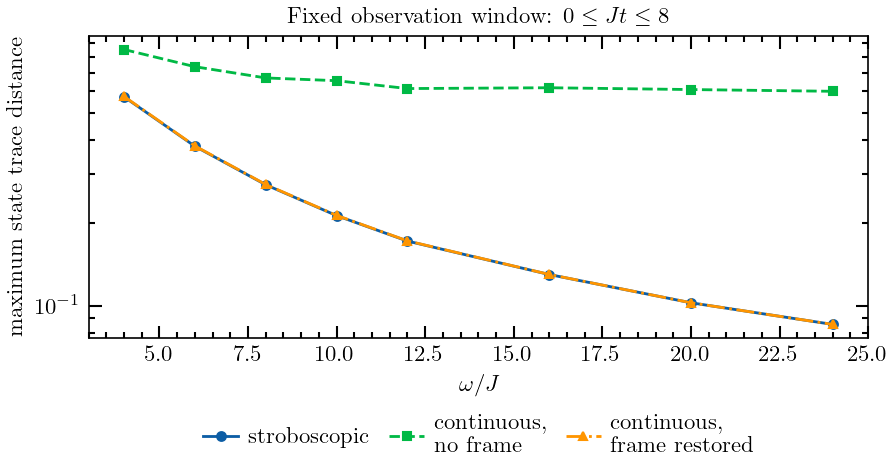

,omega_over_J,observation_window_Jt,number_of_stroboscopic_samples,max_population_error,max_stroboscopic_error,max_continuous_error_no_frame,max_continuous_error_with_frame
0,4.0,8.0,6,0.477742,0.573368,0.851289,0.575143
1,6.0,8.0,8,0.228637,0.379342,0.737384,0.380383
2,8.0,8.0,11,0.131567,0.274957,0.671266,0.275596
3,10.0,8.0,13,0.085980,0.212489,0.656044,0.212914
4,12.0,8.0,16,0.061050,0.171772,0.614303,0.172047
5,16.0,8.0,21,0.038063,0.129914,0.618487,0.129988
6,20.0,8.0,26,0.026007,0.102590,0.609193,0.102594
7,24.0,8.0,31,0.018858,0.085617,0.600385,0.085617


In [9]:
omega_scan = np.array([4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0, 24.0])
validity_rows = []

t_window = 8.0 / J
points_per_fastest_period = 60
dt = (2 * np.pi / omega_scan.max()) / points_per_fastest_period
times_fixed = np.arange(0.0, t_window + 0.5 * dt, dt)

for omega_value in omega_scan:
    T = 2 * np.pi / omega_value

    H_exact = lab_hamiltonian(J, omega_value, alpha_ordinary)
    H_eff = leading_floquet_hamiltonian(J, alpha_ordinary)

    exact = sesolve(H_exact, ket_L, times_fixed, options=SOLVER)
    eff = sesolve(H_eff, ket_L, times_fixed, options=SOLVER)

    reconstructed = [
        frame_unitary(t, omega_value, alpha_ordinary) * state
        for t, state in zip(times_fixed, eff.states)
    ]

    D_no_frame = np.array([
        tracedist(ket2dm(a), ket2dm(b))
        for a, b in zip(exact.states, eff.states)
    ])
    D_frame = np.array([
        tracedist(ket2dm(a), ket2dm(b))
        for a, b in zip(exact.states, reconstructed)
    ])

    # Evaluate exact stroboscopic times directly instead of snapping to the
    # continuous plotting grid.
    strobe_times = np.arange(0.0, t_window + 0.5 * T, T)
    strobe_times = strobe_times[strobe_times <= t_window + 1e-12]
    exact_strobe = sesolve(H_exact, ket_L, strobe_times, options=SOLVER)
    eff_strobe = sesolve(H_eff, ket_L, strobe_times, options=SOLVER)
    D_strobe = np.array([
        tracedist(ket2dm(a), ket2dm(b))
        for a, b in zip(exact_strobe.states, eff_strobe.states)
    ])

    P_exact = np.asarray(expect(P_R, exact.states), dtype=float)
    P_reconstructed = np.asarray(expect(P_R, reconstructed), dtype=float)
    max_population_error = np.max(np.abs(P_exact - P_reconstructed))

    validity_rows.append({
        "omega_over_J": omega_value / J,
        "observation_window_Jt": J * t_window,
        "number_of_stroboscopic_samples": len(strobe_times),
        "max_population_error": max_population_error,
        "max_stroboscopic_error": D_strobe.max(),
        "max_continuous_error_no_frame": D_no_frame.max(),
        "max_continuous_error_with_frame": D_frame.max(),
    })

validity = pd.DataFrame(validity_rows)
save_table(validity, "N03_D6")

fig = plt.figure(figsize=(FIG_WIDTH_150MM, 3.20))
gs = fig.add_gridspec(1, 1, left=0.105, right=0.985, bottom=0.27, top=0.90)
ax = fig.add_subplot(gs[0, 0])
ax.semilogy(
    validity["omega_over_J"],
    validity["max_stroboscopic_error"],
    "o-",
    label="stroboscopic",
)
ax.semilogy(
    validity["omega_over_J"],
    validity["max_continuous_error_no_frame"],
    "s--",
    label="continuous,\nno frame",
)
ax.semilogy(
    validity["omega_over_J"],
    validity["max_continuous_error_with_frame"],
    "^-.",
    label="continuous,\nframe restored",
)
ax.set(
    xlabel=r"$\omega/J$",
    ylabel="maximum state trace distance",
    title=r"Fixed observation window: $0\leq Jt\leq 8$",
)
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.50, -0.22),
    ncol=3,
    handlelength=1.55,
    handletextpad=0.40,
    columnspacing=0.85,
    labelspacing=0.10,
    borderaxespad=0.0,
)
save_figure(fig, "N03_F2")
plt.show()
plt.close(fig)

validity


**Figure N03_F2.** Fixed-window validity scan over $0\leq Jt\leq 8$.
The leading model improves as $\omega/J$ increases. Restoring the exact periodic
frame removes the dominant continuous-time representation error, while the
remaining discrepancy records higher-order Floquet drift and kick corrections.


## 12. Residual motion at the first Bessel zero

At $K/\omega=\alpha_0$, $J_{\rm eff}^{(0)}=0$. The exact driven system still contains higher harmonics and therefore retains finite-frequency motion. The residual transfer should decrease as the high-frequency limit is approached, but its detailed scaling depends on symmetry and on which higher-order terms survive.

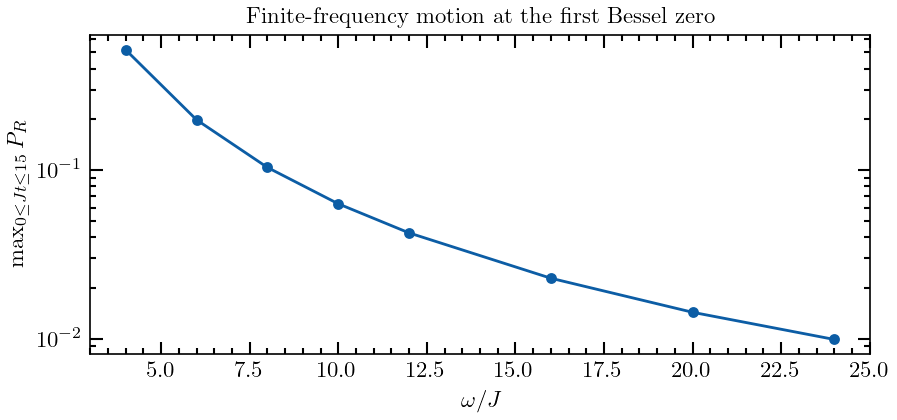

,omega_over_J,max_P_R_over_window
0,4.0,0.518206
1,6.0,0.199037
2,8.0,0.103791
3,10.0,0.063135
4,12.0,0.042394
5,16.0,0.022817
6,20.0,0.014323
7,24.0,0.009878


In [10]:
cdt_rows = []
for omega_value in omega_scan:
    times = np.linspace(0.0, 15.0 / J, 1201)
    exact = sesolve(
        lab_hamiltonian(J, omega_value, alpha_zero),
        ket_L,
        times,
        options=SOLVER,
    )
    P = np.asarray(expect(P_R, exact.states), dtype=float)
    cdt_rows.append({
        "omega_over_J": omega_value / J,
        "max_P_R_over_window": P.max(),
    })

cdt_scan = pd.DataFrame(cdt_rows)
save_table(cdt_scan, "N03_D7")

fig = plt.figure(figsize=(FIG_WIDTH_150MM, 2.95))
gs = fig.add_gridspec(1, 1, left=0.105, right=0.985, bottom=0.18, top=0.90)
ax = fig.add_subplot(gs[0, 0])
ax.semilogy(cdt_scan["omega_over_J"], cdt_scan["max_P_R_over_window"], "o-")
ax.set(
    xlabel=r"$\omega/J$",
    ylabel=r"$\max_{0\leq Jt\leq 15}P_R$",
    title="Finite-frequency motion at the first Bessel zero",
)
save_figure(fig, "N03_F3")
plt.show()
plt.close(fig)

cdt_scan


**Figure N03_F3.** Residual transfer at the first zero of $\mathcal J_0$. The Bessel zero suppresses the leading process; it does not remove all finite-frequency corrections.

## 13. Independent-learning extension II: why the sign of $J_{\rm eff}$ can be physical

For a single isolated bond, $J_{\rm eff}\to -J_{\rm eff}$ can be absorbed into a local phase convention. A three-site ring is different: the product of hopping phases around the loop is gauge invariant. Sign inversion therefore changes the ring spectrum and its interference pattern.

To isolate the sign itself, the comparison below uses **equal hopping magnitudes** $+|J_*|$ and $-|J_*|$. A comparison with unequal magnitudes would not establish a sign effect.


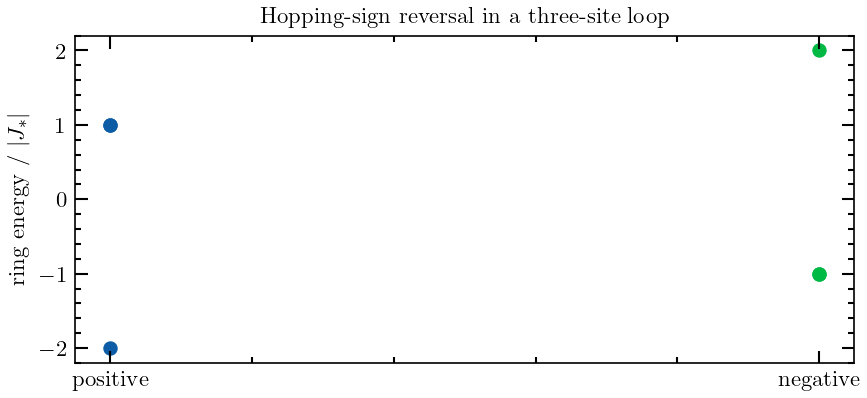

,level,positive_hopping,negative_hopping_same_magnitude
0,0,-0.640376,-0.320188
1,1,0.320188,-0.320188
2,2,0.320188,0.640376


In [11]:
def ring_hamiltonian(J_eff, sites=3):
    kets = [basis(sites, j) for j in range(sites)]
    H = 0 * qeye(sites)
    for j in range(sites):
        jp = (j + 1) % sites
        H += -J_eff * (
            kets[jp] * kets[j].dag()
            + kets[j] * kets[jp].dag()
        )
    return H

# Equal magnitude, opposite sign: this isolates the sign rather than conflating
# sign reversal with the Bessel-induced change in hopping magnitude.
J_loop = abs(J * jv(0, alpha_inverted))
ring_positive = np.sort(ring_hamiltonian(+J_loop).eigenenergies())
ring_negative = np.sort(ring_hamiltonian(-J_loop).eigenenergies())

ring_table = pd.DataFrame({
    "level": np.arange(3),
    "positive_hopping": ring_positive,
    "negative_hopping_same_magnitude": ring_negative,
})
save_table(ring_table, "N03_D8")

fig = plt.figure(figsize=(FIG_WIDTH_150MM, 2.95))
gs = fig.add_gridspec(1, 1, left=0.105, right=0.985, bottom=0.16, top=0.90)
ax = fig.add_subplot(gs[0, 0])
for x, spectrum, label in [
    (0, ring_positive, r"$+|J_*|$"),
    (1, ring_negative, r"$-|J_*|$"),
]:
    ax.scatter(np.full(3, x), spectrum / J_loop, s=35, label=label)
ax.set(
    xticks=[0, 1],
    xticklabels=["positive", "negative"],
    ylabel=r"ring energy / $|J_*|$",
    title="Hopping-sign reversal in a three-site loop",
)
save_figure(fig, "N03_F4")
plt.show()
plt.close(fig)

ring_table


**Figure N03_F4.** In a non-bipartite loop the hopping sign changes the gauge-invariant interference around the ring, so sign-inverted Floquet hopping is not merely a plotting convention.

## 14. Independent-learning extension III: interacting dimer and prethermal caution

A finite interacting dimer can exhibit drive-induced resonances and energy absorption, but it cannot by itself establish a thermodynamic heating law or a universal prethermal lifetime. The compact calculation below is therefore used only to show that the relevant high-frequency numerator includes interaction scales as well as the bare hopping.

In [12]:
def bose_hubbard_dimer(cutoff=3, J=1.0, U=2.0):
    a = tensor(destroy(cutoff), qeye(cutoff))
    b = tensor(qeye(cutoff), destroy(cutoff))
    n_a = a.dag() * a
    n_b = b.dag() * b
    ident = tensor(qeye(cutoff), qeye(cutoff))

    H0 = -J * (a.dag() * b + b.dag() * a)
    H0 += 0.5 * U * (
        n_a * (n_a - ident)
        + n_b * (n_b - ident)
    )
    X_dimer = 0.5 * (n_b - n_a)
    return H0, X_dimer

H_BH, X_BH = bose_hubbard_dimer(cutoff=3, J=J, U=2.0)
psi_BH = tensor(basis(3, 2), basis(3, 0))

interaction_rows = []
for omega_value in np.linspace(3.0, 14.0, 8):
    T = 2 * np.pi / omega_value
    periods = 12
    points_per_period = 40
    times = np.linspace(0.0, periods * T, periods * points_per_period + 1)
    H_drive = QobjEvo(
        [H_BH, [X_BH, drive_coeff]],
        args={"alpha": 2.0, "omega": omega_value},
    )
    out = sesolve(H_drive, psi_BH, times, e_ops=[H_BH], options=SOLVER)
    energy = np.asarray(out.expect[0], dtype=float)
    strobe = np.arange(0, len(times), points_per_period)
    stroboscopic_change = np.abs(energy[strobe] - energy[0])
    interaction_rows.append({
        "omega_over_J": omega_value / J,
        "max_stroboscopic_static_energy_change": stroboscopic_change.max(),
        "final_stroboscopic_static_energy_change": stroboscopic_change[-1],
    })

interaction_scan = pd.DataFrame(interaction_rows)
save_table(interaction_scan, "N03_D9")
interaction_scan


,omega_over_J,max_stroboscopic_static_energy_change,final_stroboscopic_static_energy_change
0,3.000000,2.032240,2.032240
1,4.571429,1.514353,0.025382
2,6.142857,0.845032,0.811294
3,7.714286,0.556322,0.429403
4,9.285714,0.273837,0.071465
5,10.857143,0.107313,0.073442
6,12.428571,0.087335,0.087335
7,14.000000,0.142718,0.084941


This finite dimer is an **absorption diagnostic**, not a thermodynamic heating calculation. Stroboscopic sampling removes the largest within-period micromotion from the energy comparison. Frequency-dependent structure can reveal finite-size resonant response, but a many-body prethermal claim requires system-size, observation-time, and energy-density analysis. The experimental prethermal results cited below provide that broader context.

## 15. First failure and structural repair

The leading high-frequency Hamiltonian fails for two distinct reasons:

1. **a Floquet replica becomes resonant:** one or more harmonic sectors must remain in the retained Sambe block;
2. **higher-order drift or kick terms become observable:** the van Vleck/Floquet-Magnus expansion must be carried to higher order and the observable reconstructed consistently.

A small $\mathcal J_0(\alpha)$ is especially delicate because the nominal leading process has been tuned away. The perturbative question is then controlled by the first nonzero higher-order term, not by $J_{\rm eff}^{(0)}$.

For interacting systems, heating introduces a separate time-window issue. A high-frequency effective Hamiltonian can govern a long prethermal regime without defining the asymptotic infinite-time state.

### Control scale beyond the dimer

For the minimal noninteracting dimer, $J/\omega$ is a useful high-frequency parameter. In a larger or interacting system the relevant comparison is local and sector dependent: each retained harmonic matrix element must be compared with its associated Floquet-replica denominator. Interactions, static fields, occupation-dependent bosonic factors, and the local sector explored by the state can therefore set the controlling numerator.


## 16. Method comparison

| Method | What it exposes | Main strength | Failure signal |
|---|---|---|---|
| exact periodic frame | representation change and laboratory reconstruction | separates exact kinematics from approximation | none; it is an identity |
| leading harmonic average | $J_{\rm eff}=J\mathcal J_0(\alpha)$ | immediate physical control picture | higher harmonics or replica resonance become important |
| Floquet-Magnus / van Vleck expansion | higher-order drift Hamiltonian and kick operators | systematic correction to the leading generator and reconstructed observables | asymptotic ordering deteriorates near resonant replicas |
| exact one-period propagator / QuTiP `FloquetBasis` | exact quasienergies and Floquet modes | direct stroboscopic spectral benchmark | zone folding hides branch continuity if handled carelessly |
| Sambe-space truncation | harmonic connectivity and resonant replicas | identifies which photon sectors must be retained | cutoff convergence is lost |
| exact `sesolve` dynamics | complete finite-system benchmark | tests populations, currents, and reconstructed states | accurate but not explanatory by itself |


## 17. Numerical validation

The final cell checks the exact frame identity, one-period unitarity, the high-frequency quasienergy comparison, Sambe convergence, residual coherent-destruction motion, and the distinction between stroboscopic and continuous-time errors.

In [13]:
validation = pd.DataFrame({
    "check": [
        "exact frame transformation",
        "one-period unitarity",
        "leading quasienergy accuracy",
        "Sambe cutoff improves",
        "Sambe M=6 accuracy",
        "finite-frequency motion at Bessel zero",
        "fixed-window population error improves",
        "high-frequency stroboscopic improvement",
        "periodic frame improves continuous state",
        "periodic frame improves current",
        "equal-magnitude sign inversion changes odd-ring spectrum",
    ],
    "value": [
        frame_distances.max(),
        unitarity_residual,
        quasi_residual,
        sambe_table.iloc[-1]["max_quasienergy_error"] < sambe_table.iloc[0]["max_quasienergy_error"],
        sambe_table.iloc[-1]["max_quasienergy_error"],
        P_R_cdt_exact.max(),
        validity.iloc[-1]["max_population_error"] < validity.iloc[0]["max_population_error"],
        validity.iloc[-1]["max_stroboscopic_error"] < validity.iloc[0]["max_stroboscopic_error"],
        validity.iloc[-1]["max_continuous_error_with_frame"] < validity.iloc[-1]["max_continuous_error_no_frame"],
        current_error_with_frame < current_error_no_frame,
        np.max(np.abs(ring_positive - ring_negative)) / J_loop > 0.1,
    ],
})
save_table(validation, "N03_D10")

assert frame_distances.max() < 1e-6
assert unitarity_residual < 1e-7
assert quasi_residual < 5e-2
assert sambe_table.iloc[-1]["max_quasienergy_error"] < sambe_table.iloc[0]["max_quasienergy_error"]
assert sambe_table.iloc[-1]["max_quasienergy_error"] < 1e-3
assert P_R_cdt_exact.max() > 0.0
assert validity.iloc[-1]["max_population_error"] < validity.iloc[0]["max_population_error"]
assert validity.iloc[-1]["max_stroboscopic_error"] < validity.iloc[0]["max_stroboscopic_error"]
assert validity.iloc[-1]["max_continuous_error_with_frame"] < validity.iloc[-1]["max_continuous_error_no_frame"]
assert current_error_with_frame < current_error_no_frame
assert np.max(np.abs(ring_positive - ring_negative)) / J_loop > 0.1

validation


,check,value
0,exact frame transformation,0.0
1,one-period unitarity,0.0
2,leading quasienergy accuracy,0.005841
3,Sambe cutoff improves,True
4,Sambe M=6 accuracy,0.0
5,finite-frequency motion at Bessel zero,0.042394
6,fixed-window population error improves,True
7,high-frequency stroboscopic improvement,True
8,periodic frame improves continuous state,True
9,periodic frame improves current,True


## 18. Exercises and extensions

### Derivation and Floquet-gauge exercises

1. Derive the accelerated-frame Hamiltonian explicitly from $R^\dagger H R-iR^\dagger\dot R$.
2. Starting from the Jacobi-Anger expansion, derive the Fourier block $H_m$.
3. Derive the first nonzero van Vleck correction for the driven dimer and determine which symmetry suppresses lower-order terms at the first Bessel zero.
4. Track quasienergy branches continuously as $K/\omega$ crosses a Floquet-zone boundary; compare continuous branch tracking with naive principal-zone sorting.
5. Repeat the quasienergy comparison at $\omega/J=6$ and identify the first visible finite-frequency correction.

### Resonant-replica and reconstruction exercises

6. Add a static bias $\Delta(P_R-P_L)/2$ and locate the one-photon resonance $\omega\simeq\Delta$ in Sambe space.
7. Build the minimal resonant two-replica Floquet block and compare it with the exact QuTiP quasienergies.
8. Compare the laboratory current with the rotating-frame current and with the periodic-frame reconstructed current.
9. Determine whether the first Bessel zero remains the optimal suppression point after the leading finite-frequency correction is included.

### Lattice and open-system extensions

10. Replace the dimer by a finite chain and reconstruct the wave-packet centre of mass.
11. Extend the lattice to a ring and relate the sign of $J_{\rm eff}$ to an effective loop flux.
12. Add next-nearest-neighbour hopping and determine whether one Bessel factor controls both hopping ranges.
13. Add weak dephasing and compare `mesolve` stroboscopic populations with continuous currents.

### Interacting and prethermal extensions

14. Add two interacting bosons and compare continuous-time and stroboscopic energy diagnostics.
15. Increase the interacting-system size and test whether the low-absorption interval survives as the Hilbert space grows.
16. Define a task-dependent prethermal observation window and state explicitly which observable and tolerance determine its endpoint.


## References

### Floquet tunnelling and experiments

1. D. H. Dunlap and V. M. Kenkre, “Dynamic localization of a charged particle moving under the influence of an electric field,” *Phys. Rev. B* **34**, 3625 (1986). [DOI](https://doi.org/10.1103/PhysRevB.34.3625)
2. F. Grossmann, T. Dittrich, P. Jung, and P. Hänggi, “Coherent destruction of tunneling,” *Phys. Rev. Lett.* **67**, 516 (1991). [DOI](https://doi.org/10.1103/PhysRevLett.67.516)
3. G. Della Valle, M. Ornigotti, E. Cianci, V. Foglietti, P. Laporta, and S. Longhi, “Visualization of coherent destruction of tunneling in an optical double well system,” *Phys. Rev. Lett.* **98**, 263601 (2007). [DOI](https://doi.org/10.1103/PhysRevLett.98.263601)
4. H. Lignier *et al.*, “Dynamical control of matter-wave tunneling in periodic potentials,” *Phys. Rev. Lett.* **99**, 220403 (2007). [DOI](https://doi.org/10.1103/PhysRevLett.99.220403)
5. E. Kierig, U. Schnorrberger, A. Schietinger, J. Tomkovic, and M. K. Oberthaler, “Single-particle tunneling in strongly driven double-well potentials,” *Phys. Rev. Lett.* **100**, 190405 (2008). [DOI](https://doi.org/10.1103/PhysRevLett.100.190405)
6. A. Zenesini, H. Lignier, D. Ciampini, O. Morsch, and E. Arimondo, “Coherent control of dressed matter waves,” *Phys. Rev. Lett.* **102**, 100403 (2009). [DOI](https://doi.org/10.1103/PhysRevLett.102.100403)

### Floquet and Sambe methods

7. H. Sambe, “Steady states and quasienergies of a quantum-mechanical system in an oscillating field,” *Phys. Rev. A* **7**, 2203 (1973). [DOI](https://doi.org/10.1103/PhysRevA.7.2203)
8. M. Grifoni and P. Hänggi, “Driven quantum tunneling,” *Phys. Rep.* **304**, 229 (1998).
9. N. Goldman and J. Dalibard, “Periodically driven quantum systems: Effective Hamiltonians and engineered gauge fields,” *Phys. Rev. X* **4**, 031027 (2014). [DOI](https://doi.org/10.1103/PhysRevX.4.031027)
10. M. Bukov, L. D'Alessio, and A. Polkovnikov, “Universal high-frequency behavior of periodically driven systems,” *Adv. Phys.* **64**, 139 (2015).
11. A. Eckardt and E. Anisimovas, “High-frequency approximation for periodically driven quantum systems from a Floquet-space perspective,” *New J. Phys.* **17**, 093039 (2015). [DOI](https://doi.org/10.1088/1367-2630/17/9/093039)
12. A. Eckardt, “Colloquium: Atomic quantum gases in periodically driven optical lattices,” *Rev. Mod. Phys.* **89**, 011004 (2017). [DOI](https://doi.org/10.1103/RevModPhys.89.011004)
13. L. Huang, J. Luneau, J. Schirk, F. Wallner, C. M. F. Schneider, S. Filipp, K. Liegener, and P. Rabl, “Theory of multiphoton processes for applications in quantum control,” *Phys. Rev. A* **113**, 032620 (2026). [DOI](https://doi.org/10.1103/tnkf-ckfz)

### Floquet prethermalization

14. D. A. Abanin, W. De Roeck, W. W. Ho, and F. Huveneers, “Effective Hamiltonians, prethermalization, and slow energy absorption in periodically driven many-body systems,” *Phys. Rev. B* **95**, 014112 (2017).
15. A. Rubio-Abadal *et al.*, “Floquet prethermalization in a Bose-Hubbard system,” *Phys. Rev. X* **10**, 021044 (2020). [DOI](https://doi.org/10.1103/PhysRevX.10.021044)
16. W. Beatrez *et al.*, “Floquet prethermalization with lifetime exceeding 90 s in a bulk hyperpolarized solid,” *Phys. Rev. Lett.* **127**, 170603 (2021). [DOI](https://doi.org/10.1103/PhysRevLett.127.170603)

### QuTiP

17. J. R. Johansson, P. D. Nation, and F. Nori, “QuTiP 2: A Python framework for the dynamics of open quantum systems,” *Comput. Phys. Commun.* **184**, 1234 (2013).
18. N. Lambert *et al.*, “QuTiP 5: The Quantum Toolbox in Python,” *Phys. Rep.* **1153**, 1--62 (2026). [DOI](https://doi.org/10.1016/j.physrep.2025.10.001)


In [14]:
environment = {
    "python": sys.version,
    "qutip": qt.__version__,
    "numpy": np.__version__,
    "scipy": __import__("scipy").__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "scienceplots": getattr(scienceplots, "__version__", "installed"),
    "platform": platform.platform(),
    "notebook": "N03",
}
(DATA_DIR / "N03_environment.json").write_text(
    json.dumps(environment, indent=2),
    encoding="utf-8",
)
environment

{'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]',
 'qutip': '5.2.0',
 'numpy': '2.3.2',
 'scipy': '1.16.1',
 'pandas': '3.0.6',
 'matplotlib': '3.10.5',
 'scienceplots': 'installed',
 'platform': 'Windows-10-10.0.26200-SP0',
 'notebook': 'N03'}